# Data Exploration Dataset 

The goal of this notebooks is to understand the structure and characteristics of the dataset.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [9]:
df_pd = pd.read_parquet("../revisions_no_bots.parquet")
df = pl.from_pandas(df_pd)
df

revid,parentid,minor,user,userid,timestamp,size,slots,tags,pageid,title
i64,i64,bool,str,f64,str,i64,struct[1],list[str],i64,str
1163683705,1073278143,false,"""Smasongarrison""",1.6185737e7,"""2023-07-06T02:12:52Z""",14787,"{{""wikitext"",14787}}","[""AWB""]",57185536,"""Georgia Hopley"""
1170257280,1169998062,true,"""Smasongarrison""",1.6185737e7,"""2023-08-14T00:52:02Z""",39439,"{{""wikitext"",39439}}",[],15394015,"""Willis Ward"""
1162127828,1160202917,true,"""Minorax""",3.6529075e7,"""2023-06-27T04:21:11Z""",39390,"{{""wikitext"",39390}}","[""wikieditor""]",15394015,"""Willis Ward"""
1160202917,1160202005,false,"""SheridanFord""",4.263828e6,"""2023-06-15T01:20:50Z""",39421,"{{""wikitext"",39421}}","[""visualeditor""]",15394015,"""Willis Ward"""
1160202005,1152748211,false,"""SheridanFord""",4.263828e6,"""2023-06-15T01:11:16Z""",38839,"{{""wikitext"",38839}}","[""visualeditor""]",15394015,"""Willis Ward"""
…,…,…,…,…,…,…,…,…,…,…
1135099269,1120571467,true,"""Gaius Cornelius""",293907.0,"""2023-01-22T16:53:40Z""",45682,"{{""wikitext"",45682}}","[""AWB""]",62440986,"""44 Union Square"""
1162413149,1161172203,false,"""ForsythiaJo""",4.4933079e7,"""2023-06-29T00:38:45Z""",12490,"{{""wikitext"",12490}}","[""wikieditor""]",47872332,"""The Pioneer Mother Memorial"""
1161172203,1161172179,false,"""Another Believer""",5.886041e6,"""2023-06-21T03:09:24Z""",12483,"{{""wikitext"",12483}}","[""visualeditor""]",47872332,"""The Pioneer Mother Memorial"""


## Create Graph - Reviewers+ Pages

L = 233650 
N = 43113 + 36048

In [10]:
graph_rev_pag = (
    df
    .select(["userid", "pageid"])
    .unique()
)
graph_rev_pag

userid,pageid
f64,i64
1.433803e6,5717195
4.3330104e7,1678965
3.2904124e7,48936686
3.8621216e7,57518752
262716.0,1234348
…,…
3.1439127e7,146947
1.0248457e7,1247086
4.5997801e7,46991545


In [11]:
graph_rev_pag.select("userid").unique().count()

userid
u32
43113


In [12]:
graph_rev_pag.select("pageid").unique().count()

pageid
u32
36048


## Projeção Users

In [6]:
clone_graph = graph_rev_pag.clone().rename({"userid": "userid_2"})

## Create a df with users conneting to users via pages and the total of pages shared
graph_users = (
    graph_rev_pag
    .join(clone_graph, left_on="pageid", right_on="pageid", how="inner")
    .filter(pl.col("userid") != pl.col("userid_2"))
    .group_by(["userid", "userid_2"])
    .agg(pl.count("pageid").alias("weight"))
    .rename({"userid": "from", "userid_2": "to"})
)
graph_users

from,to,weight
f64,f64,u32
1.8916437e7,2.8723648e7,1
6.27233e6,2.5524306e7,1
4.5338532e7,4.061563e7,1
3.2395809e7,4.5824205e7,1
1.3037406e7,3.9606237e7,1
…,…,…
4.3681007e7,36389.0,1
4.4372971e7,4.6479835e7,1
3.8954948e7,2.1878292e7,1


In [13]:
## calculate the the number of users (nodes) and the number of connections (edges)
L = graph_users.shape[0]
N = graph_users.select("from").unique().shape[0]
L, N

(4184680, 42679)

/tmp/ipykernel_27361/4161581555.py:5: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


<Axes: xlabel='count'>

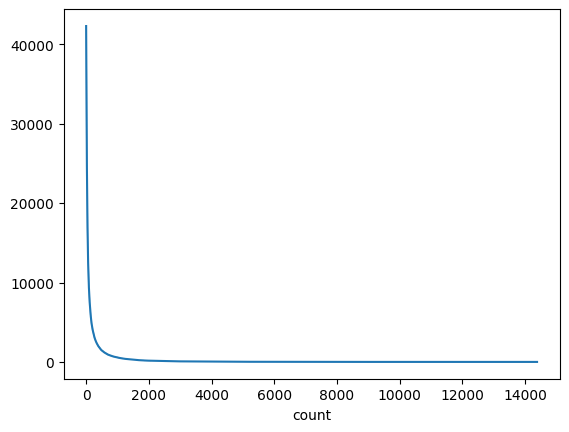

In [37]:
## degree neighboors
_from = (
    graph_users
    .group_by("from")
    .count()
    .sort("count", descending=True)
)


sns.lineplot(data=_from.to_pandas(), y=range(_from.shape[0]), x="count")

In [ ]:
## mean k
_from.select("count").mean()

count
f64
32.0
